# Comparativa de Modelos — Random Forest vs XGBoost
### TFM — Máster en IA, Big Data & Cloud | Management Solutions

Este notebook entrena dos modelos sobre el mismo split temporal y los compara en:
- Métricas de rendimiento
- Curvas ROC
- Detección de concept drift por ventanas
- Interpretabilidad SHAP

**Prerequisito:** `creditcard.csv` en la misma carpeta.

---

## 0. Instalación

In [1]:
 !pip3 install pandas numpy scikit-learn xgboost shap matplotlib seaborn scipy


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, roc_curve
)
from scipy.stats import ks_2samp
from xgboost import XGBClassifier
import shap
shap.initjs()

SEED = 42
np.random.seed(SEED)
print('Librerías cargadas')

Librerías cargadas


---
## 2. Carga y preprocesamiento

In [3]:
df = pd.read_csv('creditcard.csv')
df['hour'] = (df['Time'] // 3600).astype(int)

# Split temporal 70/30
df_sorted = df.sort_values('Time').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.70)
train_df  = df_sorted.iloc[:split_idx].copy()
test_df   = df_sorted.iloc[split_idx:].copy()

FEATURES = [c for c in df.columns if c not in ['Class', 'Time', 'hour']]

X_train = train_df[FEATURES].copy()
y_train = train_df['Class']
X_test  = test_df[FEATURES].copy()
y_test  = test_df['Class']

scaler = StandardScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount']  = scaler.transform(X_test[['Amount']])

print(f'Train: {len(X_train):,} filas  |  Test: {len(X_test):,} filas')
print(f'Fraudes en test: {y_test.sum()} ({y_test.mean()*100:.2f}%)')

Train: 199,364 filas  |  Test: 85,443 filas
Fraudes en test: 108 (0.13%)


---
## 3. Entrenamiento de ambos modelos

In [4]:
# Random Forest
print('Entrenando Random Forest...')
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Random Forest listo')

# XGBoost
# scale_pos_weight compensa el desbalanceo: n_negativos / n_positivos
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nEntrenando XGBoost (scale_pos_weight={scale_pos:.0f})...')
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    random_state=SEED,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print('XGBoost listo')

Entrenando Random Forest...
Random Forest listo

Entrenando XGBoost (scale_pos_weight=518)...
XGBoost listo


---
## 4. Comparativa de Métricas

In [5]:
def evaluar_modelo(nombre, model, X, y):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y, y_pred), 4),
        'Precision': round(precision_score(y, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y, y_proba), 4),
        '_y_pred':   y_pred,
        '_y_proba':  y_proba
    }

res_rf  = evaluar_modelo('Random Forest', rf,  X_test, y_test)
res_xgb = evaluar_modelo('XGBoost',       xgb, X_test, y_test)

metricas = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

print('=== COMPARATIVA DE MÉTRICAS ===')
print(f'{"Métrica":12s}  {"Random Forest":>14s}  {"XGBoost":>10s}  {"Ganador"}')
print('-' * 55)
for m in metricas:
    ganador = 'RF' if res_rf[m] >= res_xgb[m] else 'XGB'
    print(f'{m:12s}  {res_rf[m]:>14.4f}  {res_xgb[m]:>10.4f}  {ganador}')

# Tabla visual
df_comp = pd.DataFrame([{k: v for k, v in res_rf.items()  if not k.startswith('_')},
                         {k: v for k, v in res_xgb.items() if not k.startswith('_')}])
df_comp.set_index('Modelo')

=== COMPARATIVA DE MÉTRICAS ===
Métrica        Random Forest     XGBoost  Ganador
-------------------------------------------------------
Accuracy              0.9995      0.9994  RF
Precision             0.8557      0.7642  RF
Recall                0.7685      0.7500  RF
F1                    0.8098      0.7570  RF
ROC-AUC               0.9831      0.9828  RF


,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Random Forest,0.9995,0.8557,0.7685,0.8098,0.9831
XGBoost,0.9994,0.7642,0.7500,0.7570,0.9828


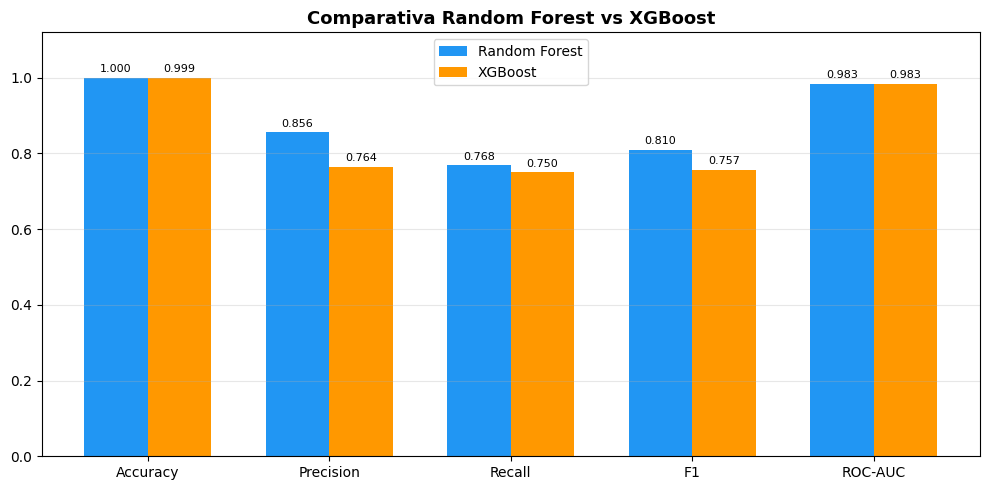

In [6]:
# Gráfico comparativo de métricas
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metricas))
w = 0.35

vals_rf  = [res_rf[m]  for m in metricas]
vals_xgb = [res_xgb[m] for m in metricas]

bars_rf  = ax.bar(x - w/2, vals_rf,  w, label='Random Forest', color='#2196F3')
bars_xgb = ax.bar(x + w/2, vals_xgb, w, label='XGBoost',       color='#FF9800')

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.12)
ax.set_title('Comparativa Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_xgb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. Matrices de Confusión y Curvas ROC

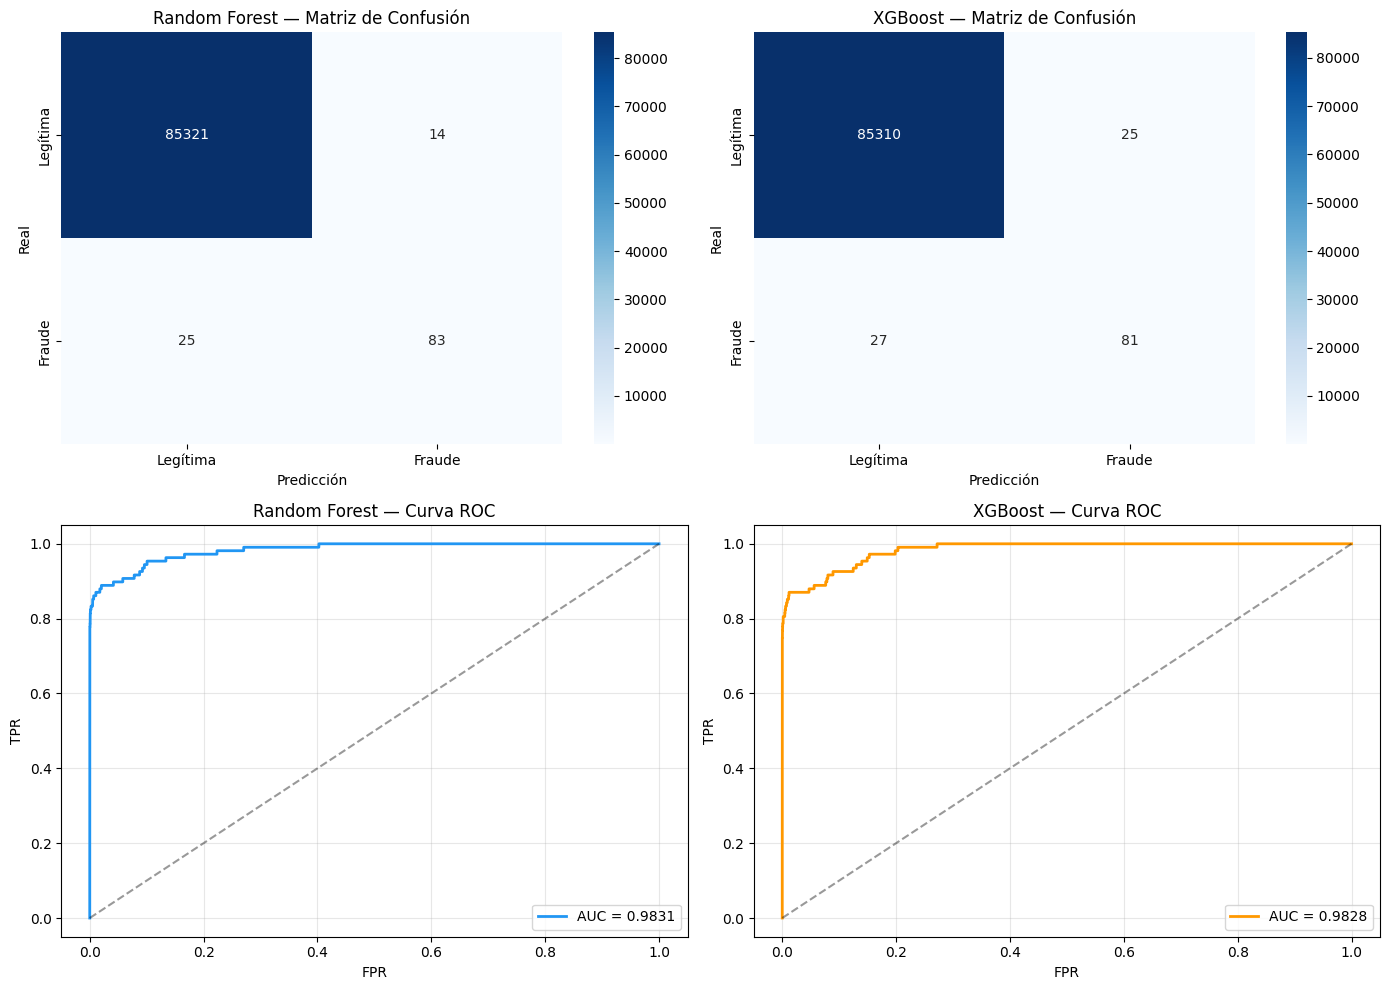

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

modelos = [
    ('Random Forest', res_rf['_y_pred'],  res_rf['_y_proba'],  '#2196F3'),
    ('XGBoost',       res_xgb['_y_pred'], res_xgb['_y_proba'], '#FF9800')
]

for col, (nombre, y_pred, y_proba, color) in enumerate(modelos):
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0][col],
                xticklabels=['Legítima', 'Fraude'],
                yticklabels=['Legítima', 'Fraude'])
    axes[0][col].set_title(f'{nombre} — Matriz de Confusión')
    axes[0][col].set_ylabel('Real')
    axes[0][col].set_xlabel('Predicción')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1][col].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    axes[1][col].plot([0, 1], [0, 1], 'k--', alpha=0.4)
    axes[1][col].set_title(f'{nombre} — Curva ROC')
    axes[1][col].set_xlabel('FPR')
    axes[1][col].set_ylabel('TPR')
    axes[1][col].legend()
    axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

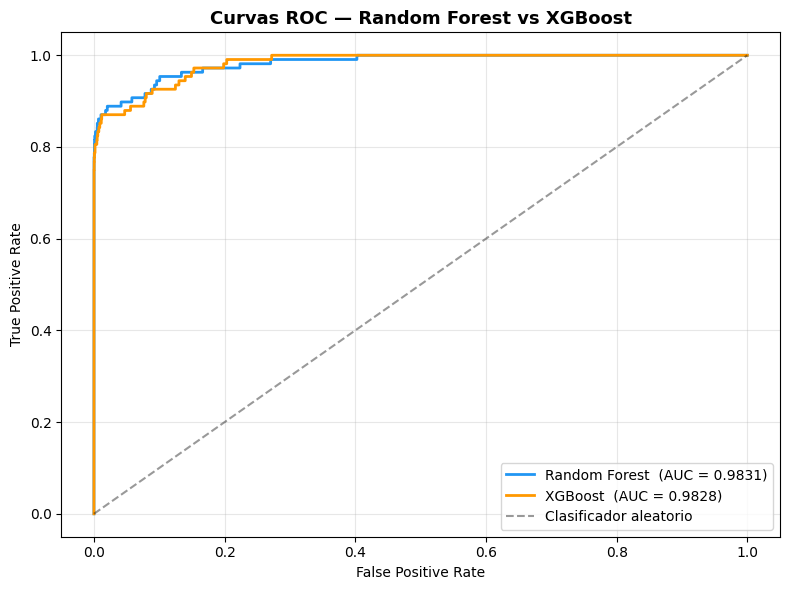

In [8]:
# Curvas ROC superpuestas para comparación directa
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, _, y_proba, color in modelos:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Clasificador aleatorio')
ax.set_title('Curvas ROC — Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Concept Drift por Ventanas Temporales

¿Qué modelo mantiene mejor el rendimiento en producción?

In [9]:
mid  = len(test_df) // 2
w1_X = X_test.iloc[:mid]
w2_X = X_test.iloc[mid:]
w1_y = y_test.iloc[:mid]
w2_y = y_test.iloc[mid:]

def metricas_ventana(model, X, y):
    yp = model.predict(X)
    yb = model.predict_proba(X)[:, 1]
    return {
        'F1':      round(f1_score(y, yp, zero_division=0), 4),
        'Recall':  round(recall_score(y, yp, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y, yb) if y.sum() > 0 else 0, 4)
    }

drift_data = {
    'Random Forest': {
        'w1': metricas_ventana(rf,  w1_X, w1_y),
        'w2': metricas_ventana(rf,  w2_X, w2_y)
    },
    'XGBoost': {
        'w1': metricas_ventana(xgb, w1_X, w1_y),
        'w2': metricas_ventana(xgb, w2_X, w2_y)
    }
}

print('=== CONCEPT DRIFT — Degradación por modelo ===')
for nombre, d in drift_data.items():
    print(f'\n{nombre}')
    print(f'  {"Métrica":10s}  {"Ventana 1":>10s}  {"Ventana 2":>10s}  {"Δ":>8s}')
    print('  ' + '-' * 42)
    for k in d['w1']:
        delta = d['w2'][k] - d['w1'][k]
        trend = '↓' if delta < -0.02 else ('↑' if delta > 0.02 else '→')
        print(f'  {k:10s}  {d["w1"][k]:>10.4f}  {d["w2"][k]:>10.4f}  {delta:>+8.4f} {trend}')

=== CONCEPT DRIFT — Degradación por modelo ===

Random Forest
  Métrica      Ventana 1   Ventana 2         Δ
  ------------------------------------------
  F1              0.8627      0.7573   -0.1054 ↓
  Recall          0.7857      0.7500   -0.0357 ↓
  ROC-AUC         0.9853      0.9810   -0.0043 →

XGBoost
  Métrica      Ventana 1   Ventana 2         Δ
  ------------------------------------------
  F1              0.7748      0.7379   -0.0369 ↓
  Recall          0.7679      0.7308   -0.0371 ↓
  ROC-AUC         0.9857      0.9800   -0.0057 →


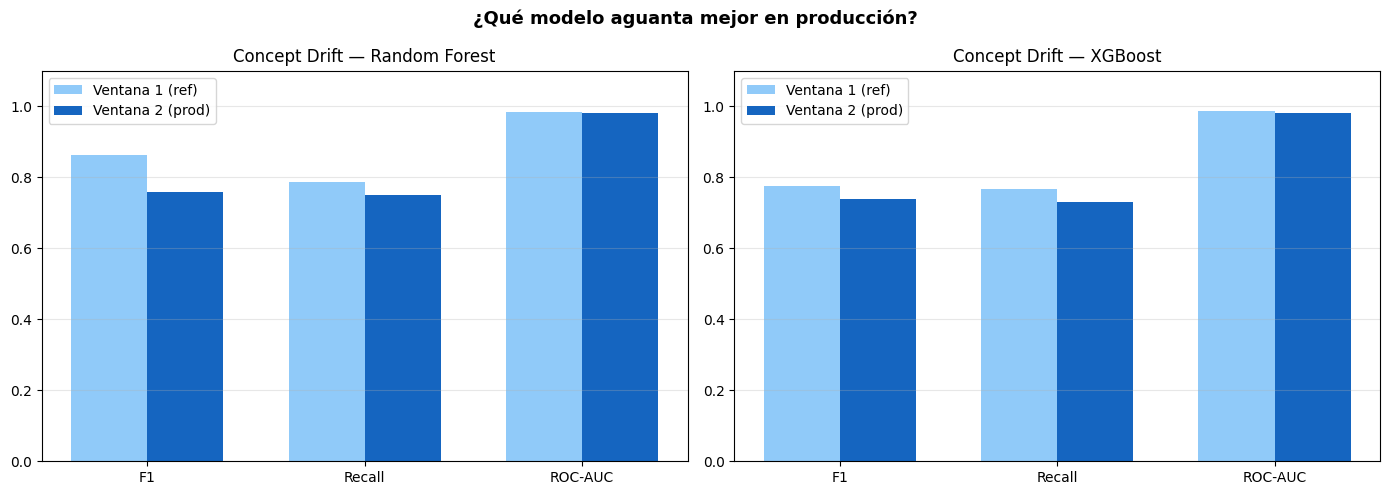

In [10]:
# Visualización del drift por modelo
metricas_drift = ['F1', 'Recall', 'ROC-AUC']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = {'Ventana 1 (ref)': '#90CAF9', 'Ventana 2 (prod)': '#1565C0'}

for ax, (nombre, d) in zip(axes, drift_data.items()):
    x = np.arange(len(metricas_drift))
    w = 0.35
    vals_w1 = [d['w1'][m] for m in metricas_drift]
    vals_w2 = [d['w2'][m] for m in metricas_drift]
    ax.bar(x - w/2, vals_w1, w, label='Ventana 1 (ref)',  color='#90CAF9')
    ax.bar(x + w/2, vals_w2, w, label='Ventana 2 (prod)', color='#1565C0')
    ax.set_xticks(x)
    ax.set_xticklabels(metricas_drift)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'Concept Drift — {nombre}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('¿Qué modelo aguanta mejor en producción?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Interpretabilidad SHAP — Comparativa

In [11]:
X_sample = X_test.sample(n=min(2000, len(X_test)), random_state=SEED)

print('Calculando SHAP para Random Forest...')
exp_rf      = shap.TreeExplainer(rf)
sv_rf       = exp_rf.shap_values(X_sample)
shap_rf     = sv_rf[1] if isinstance(sv_rf, list) else sv_rf

print('Calculando SHAP para XGBoost...')
exp_xgb     = shap.TreeExplainer(xgb)
sv_xgb      = exp_xgb.shap_values(X_sample)
shap_xgb    = sv_xgb[1] if isinstance(sv_xgb, list) else sv_xgb

print('Listo')

Calculando SHAP para Random Forest...
Calculando SHAP para XGBoost...
Listo


SHAP — Random Forest


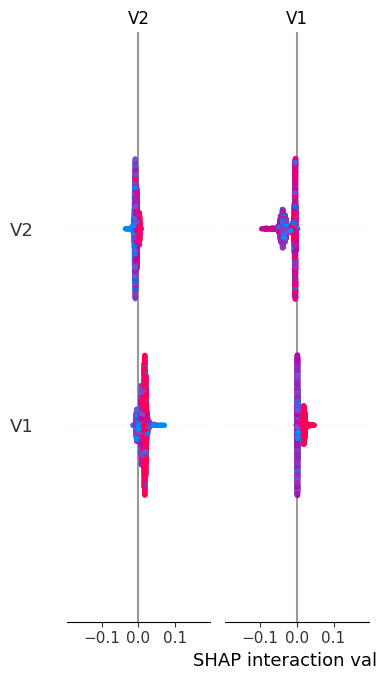

In [13]:
# Importancia global — Random Forest
print('SHAP — Random Forest')
shap.summary_plot(shap_rf, X_sample, plot_type='bar')

SHAP — XGBoost


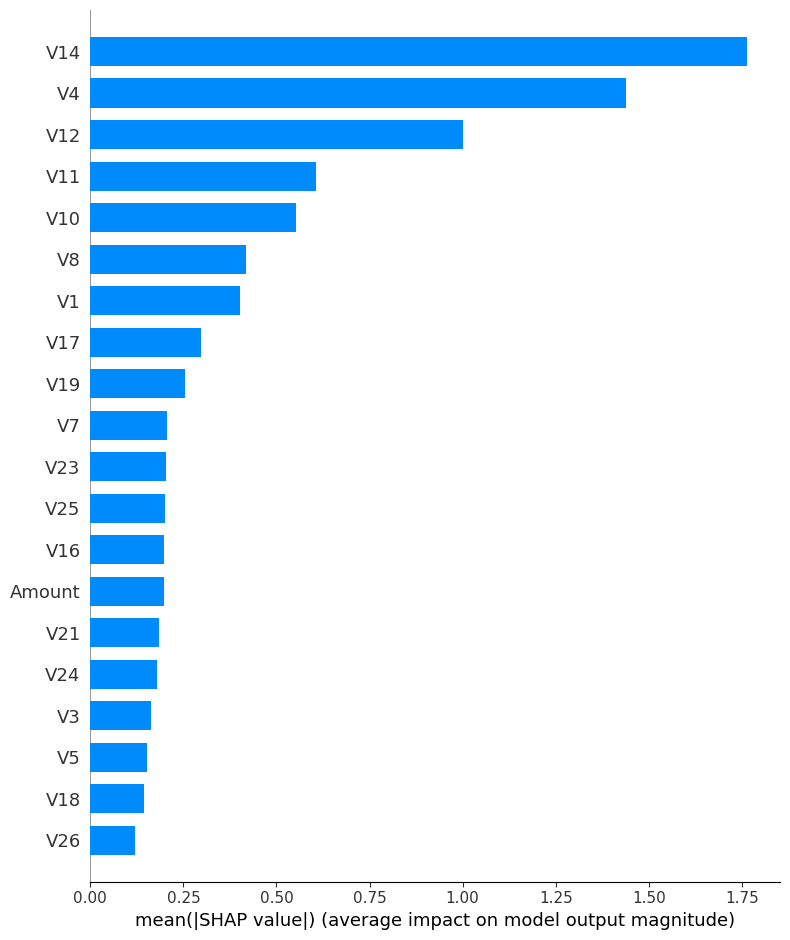

In [14]:
# Importancia global — XGBoost
print('SHAP — XGBoost')
shap.summary_plot(shap_xgb, X_sample, plot_type='bar')

In [15]:
# Comparativa: top 10 features por importancia media SHAP
imp_rf  = pd.Series(np.abs(shap_rf).mean(axis=0),  index=FEATURES).sort_values(ascending=False).head(10)
imp_xgb = pd.Series(np.abs(shap_xgb).mean(axis=0), index=FEATURES).sort_values(ascending=False).head(10)

# Unir en un único ranking
all_features = list(dict.fromkeys(imp_rf.index.tolist() + imp_xgb.index.tolist()))
rf_vals  = [np.abs(shap_rf).mean(axis=0)[FEATURES.index(f)]  for f in all_features]
xgb_vals = [np.abs(shap_xgb).mean(axis=0)[FEATURES.index(f)] for f in all_features]

df_shap = pd.DataFrame({'feature': all_features, 'RF': rf_vals, 'XGB': xgb_vals})
df_shap = df_shap.sort_values('RF', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(df_shap))
w = 0.35
ax.bar(x - w/2, df_shap['RF'],  w, label='Random Forest', color='#2196F3')
ax.bar(x + w/2, df_shap['XGB'], w, label='XGBoost',       color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(df_shap['feature'], rotation=45, ha='right')
ax.set_ylabel('Importancia media SHAP')
ax.set_title('SHAP — Importancia de Features: RF vs XGBoost', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: Data must be 1-dimensional, got ndarray of shape (29, 2) instead

---
## 8. Conclusión — ¿Qué modelo elegir?

In [16]:
print('=== RESUMEN COMPARATIVO ===')
print()

for m in metricas:
    rf_val  = res_rf[m]
    xgb_val = res_xgb[m]
    ganador = 'Random Forest' if rf_val >= xgb_val else 'XGBoost      '
    diff    = abs(rf_val - xgb_val)
    print(f'{m:12s}  RF={rf_val:.4f}  XGB={xgb_val:.4f}  -> {ganador}  (Δ={diff:.4f})')

print()
print('RECOMENDACIÓN:')
rf_score  = sum(res_rf[m]  for m in ['F1', 'Recall', 'ROC-AUC'])
xgb_score = sum(res_xgb[m] for m in ['F1', 'Recall', 'ROC-AUC'])

if xgb_score >= rf_score:
    print('  XGBoost obtiene mejor puntuación agregada en F1 + Recall + ROC-AUC.')
    print('  Es también más rápido en inferencia, lo que favorece el pipeline en GCP.')
else:
    print('  Random Forest obtiene mejor puntuación agregada en F1 + Recall + ROC-AUC.')
    print('  Es más robusto frente a datos desbalanceados con class_weight=balanced.')
print()
print('  En detección de fraude, el Recall es la métrica más crítica:')
print('  un falso negativo (fraude no detectado) tiene mayor coste que un falso positivo.')
mejor_recall = 'XGBoost' if res_xgb['Recall'] >= res_rf['Recall'] else 'Random Forest'
print(f'  Mejor Recall: {mejor_recall}')

=== RESUMEN COMPARATIVO ===

Accuracy      RF=0.9995  XGB=0.9994  -> Random Forest  (Δ=0.0001)
Precision     RF=0.8557  XGB=0.7642  -> Random Forest  (Δ=0.0915)
Recall        RF=0.7685  XGB=0.7500  -> Random Forest  (Δ=0.0185)
F1            RF=0.8098  XGB=0.7570  -> Random Forest  (Δ=0.0528)
ROC-AUC       RF=0.9831  XGB=0.9828  -> Random Forest  (Δ=0.0003)

RECOMENDACIÓN:
  Random Forest obtiene mejor puntuación agregada en F1 + Recall + ROC-AUC.
  Es más robusto frente a datos desbalanceados con class_weight=balanced.

  En detección de fraude, el Recall es la métrica más crítica:
  un falso negativo (fraude no detectado) tiene mayor coste que un falso positivo.
  Mejor Recall: Random Forest
